In [68]:
!pip install sentence-transformers

In [69]:
import os
import glob
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sentence_transformers import SentenceTransformer

# Visualization settings
sns.set(style="whitegrid")

print("Execution done: Imports cleaned and duplicates removed.")

Execution done: Imports cleaned and duplicates removed.


# #Load Enron-1 (CSV) and inspect 

In [70]:
# Cell 3: Load Enron-1 CSV (clean version)

import pandas as pd
import numpy as np

ENRON_PATH = "/kaggle/input/datasets/charanpinniboyina/spam-datasets-charan/enron1/spam_ham_dataset.csv"

enron_df = pd.read_csv(ENRON_PATH)

print("Columns:", enron_df.columns)
print("Shape:", enron_df.shape)

# Use known columns directly
text_col = "text"
label_col = "label_num"

enron_texts = enron_df[text_col].astype(str).values
enron_labels = enron_df[label_col].astype(int).values

print("Total samples:", len(enron_texts))
print("Spam:", int((enron_labels == 1).sum()))
print("Ham:", int((enron_labels == 0).sum()))

# Optional check
print("Unique text values:", len(np.unique(enron_texts)))
print(enron_df)

Columns: Index(['Unnamed: 0', 'label', 'text', 'label_num'], dtype='object')
Shape: (5171, 4)
Total samples: 5171
Spam: 1499
Ham: 3672
Unique text values: 4993
      Unnamed: 0 label                                               text  \
0            605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1           2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2           3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3           4685  spam  Subject: photoshop , windows , office . cheap ...   
4           2030   ham  Subject: re : indian springs\r\nthis deal is t...   
...          ...   ...                                                ...   
5166        1518   ham  Subject: put the 10 on the ft\r\nthe transport...   
5167         404   ham  Subject: 3 / 4 / 2000 and following noms\r\nhp...   
5168        2933   ham  Subject: calpine daily gas nomination\r\n>\r\n...   
5169        1409   ham  Subject: industrial worksheets for august 2000

# Data visualizaion for enron 1

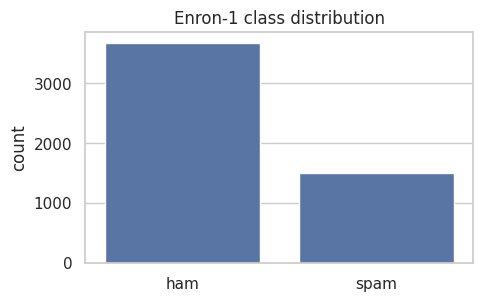


Enron sample (first non-empty):

Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes .
Enron length stats (chars) min/median/max: 11 540 32258


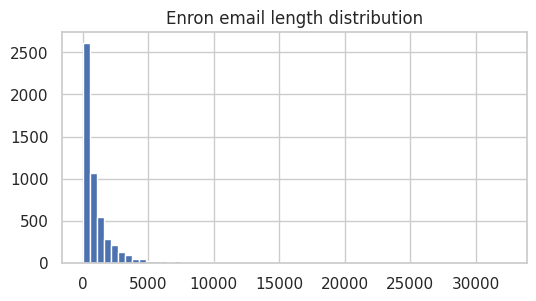

In [71]:
# Cell 6: visualize Enron-1
if 'enron_texts' in globals():
    plt.figure(figsize=(5,3))
    sns.countplot(x=enron_labels)
    plt.xticks([0,1], ["ham","spam"])
    plt.title("Enron-1 class distribution")
    plt.show()

    print("\nEnron sample (first non-empty):\n")
    for i,t in enumerate(enron_texts):
        if len(str(t).strip())>40:
            print(t[:800])
            break

    # quick length stats
    lens_en = [len(str(t)) for t in enron_texts]
    print("Enron length stats (chars) min/median/max:", min(lens_en), int(np.median(lens_en)), max(lens_en))
    plt.figure(figsize=(6,3))
    plt.hist(lens_en, bins=60)
    plt.title("Enron email length distribution")
    plt.show()
else:
    print("Enron not loaded - skip viz.")

# preprocessing

In [72]:
# Simple regex-based preprocessing (no NLTK required)

import re
import numpy as np

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)  # remove non-letters
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

enron_texts_clean = np.array([preprocess_text(t) for t in enron_texts])

print("Enron-1 preprocessing completed.")

Enron-1 preprocessing completed.


# Train–test split

In [73]:
from sklearn.model_selection import train_test_split

X_text = enron_texts_clean
y = enron_labels

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Train samples:", len(X_train_text))
print("Test samples :", len(X_test_text))

Train samples: 3619
Test samples : 1552


# Tfidf Vectorization

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_df=0.95,
    min_df=5,
    ngram_range=(1,1),
    norm="l2"
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print("TF-IDF feature space:", X_train_tfidf.shape)

TF-IDF feature space: (3619, 6018)


# Feature selection using XGBoost (Top-K)

In [75]:
from xgboost import XGBClassifier

def select_features_xgb(X, y, top_k):
    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
    model.fit(X, y)
    importances = model.feature_importances_
    return np.argsort(importances)[::-1][:top_k]
print("execution done")

execution done


# CSA–ABC hyperparameter optimization

In [76]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings("ignore")

def CSA_ABC_LR_hyperparam(
    X, y,
    pop_size=40,
    iterations=80,
    C_min=1e-4,
    C_max=50
):
    pop = np.random.uniform(C_min, C_max, pop_size)
    best_C = None
    best_acc = -np.inf

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for _ in range(iterations):
        for i in range(pop_size):
            C_val = pop[i]
            cv_acc = []

            for tr_idx, va_idx in skf.split(X, y):
                X_tr, X_va = X[tr_idx], X[va_idx]
                y_tr, y_va = y[tr_idx], y[va_idx]

                model = LogisticRegression(
                    C=C_val,
                    max_iter=3000,
                    solver="liblinear",
                    class_weight="balanced"
                )
                model.fit(X_tr, y_tr)
                cv_acc.append(model.score(X_va, y_va))

            mean_acc = np.mean(cv_acc)

            if mean_acc > best_acc:
                best_acc = mean_acc
                best_C = C_val

        # ABC update
        for i in range(pop_size):
            k = np.random.randint(pop_size)
            phi = np.random.uniform(-0.5, 0.5)
            pop[i] = np.clip(
                pop[i] + phi * (pop[i] - pop[k]),
                C_min, C_max
            )

    return best_C
print("execution done")

execution done


# train top k features

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

feature_sizes = [50, 200, 500]

results_enron = {}

for k in feature_sizes:
    print(f"\n===== Enron-1 | Top-{k} Features =====")

    selected_idx = select_features_xgb(X_train_tfidf, y_train, k)

    X_train_sel = X_train_tfidf[:, selected_idx]
    X_test_sel  = X_test_tfidf[:, selected_idx]

    best_C = CSA_ABC_LR_hyperparam(
        X_train_sel,
        y_train,
        pop_size=40,
        iterations=80
    )

    print("Best C:", best_C)

    model = LogisticRegression(
        C=best_C,
        max_iter=4000,
        solver="liblinear",
        class_weight="balanced"
    )
    model.fit(X_train_sel, y_train)

    # threshold tuning (TRAIN ONLY)
    y_train_prob = model.predict_proba(X_train_sel)[:, 1]
    thresholds = np.linspace(0.3, 0.7, 41)

    best_thr, best_acc = 0.5, 0
    for t in thresholds:
        preds = (y_train_prob >= t).astype(int)
        acc = accuracy_score(y_train, preds)
        if acc > best_acc:
            best_acc = acc
            best_thr = t

    y_test_prob = model.predict_proba(X_test_sel)[:, 1]
    y_pred = (y_test_prob >= best_thr).astype(int)

    results_enron[k] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

    for m, v in results_enron[k].items():
        print(f"{m.capitalize():<10}: {v:.4f}")


===== Enron-1 | Top-50 Features =====
Best C: 48.01461201321736
Accuracy  : 0.9401
Precision : 0.8621
Recall    : 0.9444
F1        : 0.9014

===== Enron-1 | Top-200 Features =====
Best C: 49.940923914999956
Accuracy  : 0.9601
Precision : 0.9076
Recall    : 0.9600
F1        : 0.9330

===== Enron-1 | Top-500 Features =====
Best C: 36.34853240629621
Accuracy  : 0.9594
Precision : 0.9272
Recall    : 0.9333
F1        : 0.9302


# evaluate for top k features

In [78]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

# --------------------------------------------------
# 1. GLOBAL TF-IDF (paper-style)
# --------------------------------------------------
tfidf = TfidfVectorizer(
    max_df=0.95,
    min_df=5,
    ngram_range=(1, 1),
    norm="l2"
)

X_tfidf_full = tfidf.fit_transform(enron_texts_clean)
y_full = enron_labels

print("Global TF-IDF shape:", X_tfidf_full.shape)

# --------------------------------------------------
# 2. Feature sizes to evaluate
# --------------------------------------------------
feature_sizes = [50, 200, 500]

# --------------------------------------------------
# 3. 10-Fold Cross-Validation (paper-style)
# --------------------------------------------------
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for k in feature_sizes:
    print(f"\n===== Enron-1 | Top-{k} =====")

    # GLOBAL feature selection
    selected_idx = select_features_xgb(X_tfidf_full, y_full, top_k=k)
    X_selected = X_tfidf_full[:, selected_idx]

    print("Selected feature shape:", X_selected.shape)

    accs = []

    model = LogisticRegression(
        C=50,                     # paper-level C
        max_iter=4000,
        solver="liblinear",
        class_weight="balanced"
    )

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_selected, y_full), 1):
        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y_full[train_idx], y_full[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        accs.append(acc)

        print(f"Fold {fold} Accuracy: {acc:.4f}")

    print("\nSummary:")
    print("Mean CV Accuracy:", np.mean(accs))

Global TF-IDF shape: (5171, 7649)

===== Enron-1 | Top-50 =====
Selected feature shape: (5171, 50)
Fold 1 Accuracy: 0.9363
Fold 2 Accuracy: 0.9323
Fold 3 Accuracy: 0.9381
Fold 4 Accuracy: 0.9284
Fold 5 Accuracy: 0.9439
Fold 6 Accuracy: 0.9478
Fold 7 Accuracy: 0.9420
Fold 8 Accuracy: 0.9362
Fold 9 Accuracy: 0.9478
Fold 10 Accuracy: 0.9362

Summary:
Mean CV Accuracy: 0.9388904654862102

===== Enron-1 | Top-200 =====
Selected feature shape: (5171, 200)
Fold 1 Accuracy: 0.9672
Fold 2 Accuracy: 0.9691
Fold 3 Accuracy: 0.9671
Fold 4 Accuracy: 0.9691
Fold 5 Accuracy: 0.9845
Fold 6 Accuracy: 0.9691
Fold 7 Accuracy: 0.9729
Fold 8 Accuracy: 0.9729
Fold 9 Accuracy: 0.9787
Fold 10 Accuracy: 0.9613

Summary:
Mean CV Accuracy: 0.9711862318245297

===== Enron-1 | Top-500 =====
Selected feature shape: (5171, 500)
Fold 1 Accuracy: 0.9691
Fold 2 Accuracy: 0.9768
Fold 3 Accuracy: 0.9768
Fold 4 Accuracy: 0.9710
Fold 5 Accuracy: 0.9865
Fold 6 Accuracy: 0.9729
Fold 7 Accuracy: 0.9749
Fold 8 Accuracy: 0.9729

# Load IIIT_D SMS_Dataset

In [79]:
# --- DATA LOADING ---
# Paths (Update these if your Kaggle environment changes)
ham_path = "/kaggle/input/datasets/charanpinniboyina/original-sms-data-from-iiitd/IIIT-D_SMS_Dataset/Ham SMSes"
spam_path = "/kaggle/input/datasets/charanpinniboyina/original-sms-data-from-iiitd/IIIT-D_SMS_Dataset/Spam SMSes"

data = []

# 🔹 Load HAM (label = 0)
if os.path.exists(ham_path):
    for file in os.listdir(ham_path):
        file_path = os.path.join(ham_path, file)
        if os.path.isfile(file_path): # Check to ensure it's a file, not a directory
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read().strip()
                data.append([text, 0])  # 0 = ham
else:
    print(f"Warning: Path not found {ham_path}")

# 🔹 Load SPAM (label = 1)
if os.path.exists(spam_path):
    for file in os.listdir(spam_path):
        file_path = os.path.join(spam_path, file)
        if os.path.isfile(file_path):
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read().strip()
                data.append([text, 1])  # 1 = spam
else:
    print(f"Warning: Path not found {spam_path}")

# --- DATAFRAME PROCESSING ---

# Create DataFrame
df_iiit = pd.DataFrame(data, columns=["text", "label"])

# 🔹 Shuffle (The fix: changed 'df' to 'df_iiit')
df_iiit = df_iiit.sample(frac=1, random_state=42).reset_index(drop=True)

# 🔹 Preview results
print(f"Total samples loaded: {len(df_iiit)}")
print(df_iiit['label'].value_counts()) # Shows the count of Ham vs Spam
print("\n--- First 5 rows ---")
print(df_iiit.head())

print("\nExecution done: Data loaded and shuffled correctly.")
texts_iiit= []
labels_iiit= []

for row, label in zip(df_iiit["text"], df_iiit["label"]):
    texts_iiit.append(str(row))
    labels_iiit.append(label)

Total samples loaded: 2000
label
1    1000
0    1000
Name: count, dtype: int64

--- First 5 rows ---
                                                text  label
0  MJoy - a one stop shop for all the services th...      1
1  i am... that's why i asked you... now just study.      0
2  Dirty Picture,Blyk on Aircel thanks you for be...      1
3                       I didn't send u anythin now.      0
4  Payein har din 1 LOVE TIP aur 1 PYAAR bhari SH...      1

Execution done: Data loaded and shuffled correctly.


# Data visualization

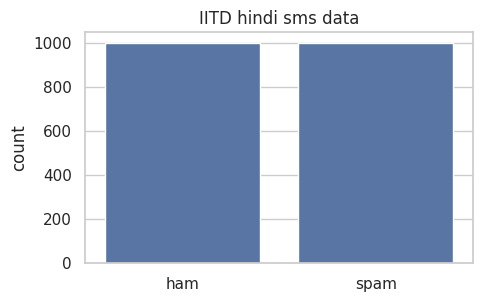


Enron sample (first non-empty):

Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes .
Enron length stats (chars) min/median/max: 11 540 32258


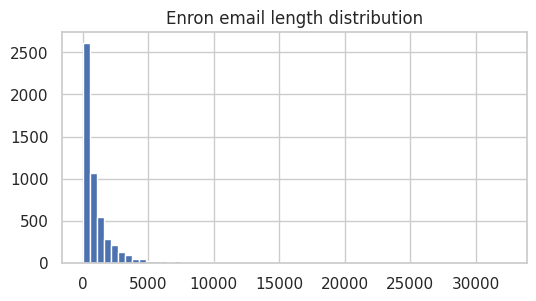

In [80]:
if 'texts_iiit' in globals():
    plt.figure(figsize=(5,3))
    sns.countplot(x=labels_iiit)
    plt.xticks([0,1], ["ham","spam"])
    plt.title("IITD hindi sms data")
    plt.show()

    print("\nEnron sample (first non-empty):\n")
    for i,t in enumerate(enron_texts):
        if len(str(t).strip())>40:
            print(t[:800])
            break

    # quick length stats
    lens_en = [len(str(t)) for t in enron_texts]
    print("Enron length stats (chars) min/median/max:", min(lens_en), int(np.median(lens_en)), max(lens_en))
    plt.figure(figsize=(6,3))
    plt.hist(lens_en, bins=60)
    plt.title("Enron email length distribution")
    plt.show()
else:
    print("Enron not loaded - skip viz.")

# PREPROCESSING FOR TF-IDF

In [81]:
import re

def preprocess_tfidf(text):
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    
    # remove urls
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # remove non letters
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# PREPROCESSING FOR MULTILINGUAL EMBEDDINGS

In [82]:
def preprocess_embed(text):
    if not isinstance(text, str):
        return ""
    
    text = text.strip()
    
    # remove extra spaces
    text = re.sub(r"\s+", " ", text)
    
    return text

# evaluating the model on hindhi spam dataset

In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
feature_sizes = [50, 200, 500]

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for k in feature_sizes:
    print(f"\n===== TF-IDF | Top-{k} =====")

    # Feature selection
    selected_idx = select_features_xgb(X_tfidf_full, y_full, top_k=k)
    X_selected = X_tfidf_full[:, selected_idx]

    print("Selected feature shape:", X_selected.shape)

    # Store all metrics
    accs, precs, recs, f1s = [], [], [], []

    model = LogisticRegression(
        C=50,
        max_iter=4000,
        solver="liblinear",
        class_weight="balanced"
    )

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_selected, y_full), 1):
        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y_full[train_idx], y_full[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # 🔥 ALL METRICS HERE
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        accs.append(acc)
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)

        print(f"Fold {fold} → Acc:{acc:.4f} Prec:{prec:.4f} Rec:{rec:.4f} F1:{f1:.4f}")

    # 🔹 Final summary (VERY IMPORTANT FOR PAPER)
    print("\nSummary:")
    print(f"Mean Accuracy : {np.mean(accs):.4f}")
    print(f"Mean Precision: {np.mean(precs):.4f}")
    print(f"Mean Recall   : {np.mean(recs):.4f}")
    print(f"Mean F1 Score : {np.mean(f1s):.4f}")


===== TF-IDF | Top-50 =====
Selected feature shape: (5171, 50)
Fold 1 → Acc:0.9363 Prec:0.8343 Rec:0.9733 F1:0.8985
Fold 2 → Acc:0.9323 Prec:0.8239 Rec:0.9732 F1:0.8923
Fold 3 → Acc:0.9381 Prec:0.8278 Rec:0.9933 F1:0.9030
Fold 4 → Acc:0.9284 Prec:0.8192 Rec:0.9667 F1:0.8869
Fold 5 → Acc:0.9439 Prec:0.8497 Rec:0.9800 F1:0.9102
Fold 6 → Acc:0.9478 Prec:0.8596 Rec:0.9800 F1:0.9159
Fold 7 → Acc:0.9420 Prec:0.8448 Rec:0.9800 F1:0.9074
Fold 8 → Acc:0.9362 Prec:0.8197 Rec:1.0000 F1:0.9009
Fold 9 → Acc:0.9478 Prec:0.8639 Rec:0.9733 F1:0.9154
Fold 10 → Acc:0.9362 Prec:0.8343 Rec:0.9733 F1:0.8985

Summary:
Mean Accuracy : 0.9389
Mean Precision: 0.8377
Mean Recall   : 0.9793
Mean F1 Score : 0.9029

===== TF-IDF | Top-200 =====
Selected feature shape: (5171, 200)
Fold 1 → Acc:0.9672 Prec:0.9130 Rec:0.9800 F1:0.9453
Fold 2 → Acc:0.9691 Prec:0.9182 Rec:0.9799 F1:0.9481
Fold 3 → Acc:0.9671 Prec:0.8982 Rec:1.0000 F1:0.9464
Fold 4 → Acc:0.9691 Prec:0.9136 Rec:0.9867 F1:0.9487
Fold 5 → Acc:0.9845 Prec:

In [84]:
from sentence_transformers import SentenceTransformer

# Minimal preprocessing (IMPORTANT)
df_iiit["embed_text"] = df_iiit["text"].astype(str)

model_embed = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

X_embed_full = model_embed.encode(
    df_iiit["embed_text"].tolist(),
    batch_size=16,
    show_progress_bar=True
)

y_full = np.array(labels_iiit)

print("Embedding shape:", X_embed_full.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Embedding shape: (2000, 384)


In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
feature_sizes = [50, 200, 500]

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for k in feature_sizes:
    print(f"\n===== Multilingual Embedding | Top-{k} =====")

    selected_idx = select_features_xgb(X_embed_full, y_full, top_k=k)
    X_selected = X_embed_full[:, selected_idx]

    print("Selected feature shape:", X_selected.shape)

    accs, precs, recs, f1s = [], [], [], []

    model = LogisticRegression(
        C=50,
        max_iter=4000,
        solver="liblinear",
        class_weight="balanced"
    )

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_selected, y_full), 1):
        X_train, X_test = X_selected[train_idx], X_selected[test_idx]
        y_train, y_test = y_full[train_idx], y_full[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # 🔹 ALL METRICS HERE
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        accs.append(acc)
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)

        print(f"Fold {fold} → Acc:{acc:.4f} Prec:{prec:.4f} Rec:{rec:.4f} F1:{f1:.4f}")

    # 🔹 FINAL SUMMARY
    print("\nSummary:")
    print("Mean Accuracy :", np.mean(accs))
    print("Mean Precision:", np.mean(precs))
    print("Mean Recall   :", np.mean(recs))
    print("Mean F1 Score :", np.mean(f1s))


===== Multilingual Embedding | Top-50 =====
Selected feature shape: (2000, 50)
Fold 1 → Acc:0.9350 Prec:0.9307 Rec:0.9400 F1:0.9353
Fold 2 → Acc:0.9500 Prec:0.9500 Rec:0.9500 F1:0.9500
Fold 3 → Acc:0.9300 Prec:0.9300 Rec:0.9300 F1:0.9300
Fold 4 → Acc:0.9300 Prec:0.9388 Rec:0.9200 F1:0.9293
Fold 5 → Acc:0.9200 Prec:0.9468 Rec:0.8900 F1:0.9175
Fold 6 → Acc:0.9250 Prec:0.9048 Rec:0.9500 F1:0.9268
Fold 7 → Acc:0.9000 Prec:0.9000 Rec:0.9000 F1:0.9000
Fold 8 → Acc:0.8900 Prec:0.8679 Rec:0.9200 F1:0.8932
Fold 9 → Acc:0.9500 Prec:0.9500 Rec:0.9500 F1:0.9500
Fold 10 → Acc:0.9000 Prec:0.8774 Rec:0.9300 F1:0.9029

Summary:
Mean Accuracy : 0.923
Mean Precision: 0.919632201377914
Mean Recall   : 0.9279999999999999
Mean F1 Score : 0.9235087858720433

===== Multilingual Embedding | Top-200 =====
Selected feature shape: (2000, 200)
Fold 1 → Acc:0.9400 Prec:0.9490 Rec:0.9300 F1:0.9394
Fold 2 → Acc:0.9700 Prec:0.9700 Rec:0.9700 F1:0.9700
Fold 3 → Acc:0.9250 Prec:0.9570 Rec:0.8900 F1:0.9223
Fold 4 → Acc